## Notebook to learn to play with tif images

In [1]:
import os
import sys
import random
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt
import torch

from utils import utils
import methods
from data_builder import build_tags
from data_builder import data_loader
from model_builder import build_model
import trainer.metrics as metrics_module

from trainer.trainer import Trainer

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"pytorch version = {torch.__version__}")

python version = 3.12.0 | packaged by conda-forge | (main, Oct  3 2023, 08:36:57) [Clang 15.0.7 ]
numpy version = 1.26.4
pytorch version = 2.1.2.post3


In [3]:
# GET config
EXP_NAME = "exp_001"
config = utils.get_config(EXP_NAME)
config["mode"] = "training"
display(config)

# SET RANDOM SEEDS
torch.manual_seed(config["seed"])
torch.cuda.manual_seed(config["seed"])
np.random.seed(config["seed"])
random.seed(config["seed"])
torch.backends.cudnn.deterministic = True

# SET DIRECTORIES
directory_paths = methods.get_directories()
FIGURE_DIRECTORY = directory_paths["figures_dir"]

{'exp_name': 'exp_001',
 'device': 'gpu',
 'seed': 22,
 'mode': 'training',
 'training_years': [2019],
 'inference_years': [2020],
 'training_region': [33, 34, 71, 72],
 'inference_region': [-90, 90, -180, 180],
 'channels': [1, 2, 3, 4, 5, 6],
 'scene_width': 11,
 'nbatches': [750, 25],
 'batches_per_epoch': 750,
 'inference_chunksize': 5000,
 'rng_seed': 33,
 'filters': [64, 128, 128, 128, 128],
 'cnn_activation': ['ReLU', 'ReLU', 'ReLU', 'ReLU', 'ReLU'],
 'kernel_size': [3, 3, 3, 3, 3],
 'dense_units': [32],
 'dense_in': [14148],
 'dense_activations': ['ReLU'],
 'final_in': 32,
 'final_activation': 'Sigmoid',
 'aug_randomflip': True,
 'input_noise': 5,
 'sample_weights_alpha': 15.0,
 'subsample': True,
 'dropout': 0.1,
 'batch_size': 32,
 'pickup_where_leftoff': False,
 'save_best_only': True,
 'trainer': {'max_epochs': 5,
  'early_stopping': {'args': {'patience': 3, 'min_delta': 0.0}}},
 'optimizer': {'type': 'Adam',
  'args': {'lr': 0.001, 'weight_decay': 0, 'amsgrad': False}},
 '

In [4]:
from torchvision.transforms import v2

# LOAD THE DATA
tags_train, tags_val = build_tags.get_tags(config)

ds_train = data_loader.CustomData(config, tags_train)
train_loader = torch.utils.data.DataLoader(
    ds_train,
    # batch_size=config["batch_size"],
    batch_size=None,
    batch_sampler=None,
    shuffle=True,
    drop_last=False,
)

ds_val = data_loader.CustomData(config, tags_val)
val_loader = torch.utils.data.DataLoader(
    ds_val,
    # batch_size=config["batch_size"],
    batch_size=None,
    batch_sampler=None,
    shuffle=False,
    drop_last=False,
)

# tfds_train = build_data.build_tf_dataset(config, tags_train, config["batch_size"])
# tfds_val = build_data.build_tf_dataset(config, tags_val, config["batch_size"])

# batch_shape = np.shape(next(tfds_val.as_numpy_iterator())[0])
# print(f"{batch_shape = }")

33.0 34.0 71.0 72.0


landsat_34lat_71lon_2019
...frac_land.round(3) = 1.0, # samples = 24800

total training samples = 23712, total validation samples = 1088



In [5]:
x, y = train_loader.dataset[0]
print(f"{x.shape = }")
print(f"{y.shape = }")

x.shape = torch.Size([32, 6, 110, 110])
y.shape = torch.Size([32, 1])
y=tensor([[36.],
        [18.],
        [26.],
        [29.],
        [48.],
        [18.],
        [37.],
        [27.],
        [30.],
        [23.],
        [19.],
        [28.],
        [13.],
        [25.],
        [25.],
        [27.],
        [29.],
        [44.],
        [28.],
        [24.],
        [17.],
        [26.],
        [25.],
        [25.],
        [23.],
        [32.],
        [33.],
        [53.],
        [29.],
        [32.],
        [39.],
        [22.]])


In [6]:
for batch_idx, (data, target) in enumerate(train_loader):
    print(f"{batch_idx = }")
    print(f"{data.shape = }")
    print(f"{target.shape = }")
    break

batch_idx = 0
data.shape = torch.Size([32, 6, 110, 110])
target.shape = torch.Size([32, 1])


In [7]:
import torchinfo

imp.reload(build_model)

# BUILD THE MODEL
model = build_model.TorchModel(config)

# print the model summary
input_shape = (
    64,
    len(config["channels"]),
    config["scene_width_landsat"],
    config["scene_width_landsat"],
)
# torchinfo.summary(
#     model,
#     input_shape,
#     verbose=1,
#     col_names=("input_size", "output_size", "num_params"),
# )

In [8]:
# Setup the optimizer, loss function, and metrics
optimizer = getattr(torch.optim, config["optimizer"]["type"])(
    model.parameters(), **config["optimizer"]["args"]
)
criterion = torch.nn.MSELoss()
metric_funcs = [getattr(metrics_module, met) for met in config["metrics"]]

# BUILD THE TRAINER
device = utils.prepare_device(config["device"])
trainer = Trainer(
    model,
    criterion,
    metric_funcs,
    optimizer,
    max_epochs=config["trainer"]["max_epochs"],
    data_loader=train_loader,
    validation_data_loader=val_loader,
    device=device,
    config=config,
)

In [9]:
# Train the Model
model.to(device)
trainer.fit()

Epoch   0/ 5
  102.7s - train_loss: 99.48179 - val_loss: 82.17908
Epoch   1/ 5
  104.3s - train_loss: 81.77038 - val_loss: 72.33131
Epoch   2/ 5
  104.8s - train_loss: 77.24768 - val_loss: 66.18833
Epoch   3/ 5
  104.7s - train_loss: 75.81867 - val_loss: 67.70381
Epoch   4/ 5
  104.6s - train_loss: 72.46318 - val_loss: 70.23803
Restoring model weights from the end of the best epoch 2: val_loss = 66.18833
  epoch = 2.00000
  loss = 77.24768
  val_loss = 66.18833
  custom_mae = 6.40074
  val_custom_mae = 5.72452


dict_keys(['epoch', 'loss', 'val_loss', 'custom_mae', 'val_custom_mae'])


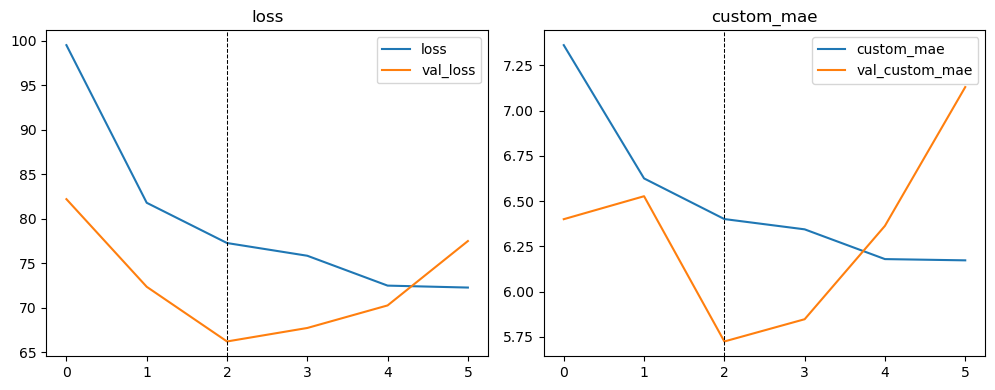

In [10]:
print(trainer.log.history.keys())

plt.figure(figsize=(20, 4))
for i, m in enumerate(("loss", *config["metrics"])):
    plt.subplot(1, 4, i + 1)
    plt.plot(trainer.log.history["epoch"], trainer.log.history[m], label=m)
    plt.plot(
        trainer.log.history["epoch"], trainer.log.history["val_" + m], label="val_" + m
    )
    plt.axvline(
        x=trainer.early_stopper.best_epoch, linestyle="--", color="k", linewidth=0.75
    )
    plt.title(m)
    plt.legend()
plt.tight_layout()
plt.show()

In [12]:
print("training complete.")

training complete.
